In [15]:
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import bayesflow as bf
import tensorflow as tf
matplotlib.rcParams["figure.dpi"] = 72

In [16]:
def prior(mu=0.0, sigma=1.0, alpha=2.0, beta=1.0):
    """
    返回一个形状为 (2,) 的向量 [mu_sample, sigma2_sample]，
    其中 mu_sample ~ N(mu, sigma^2),
         sigma2_sample ~ Inv-Gamma(alpha, beta).
    """
    rng = np.random.default_rng()

    # 从正态采一个点
    mu_sample = rng.normal(loc=mu, scale=sigma)
    # 从 Gamma(α=alpha, θ=1/beta) 中采一个点，再取其倒数 -> InvGamma
    sigma2_sample = 1.0 / rng.gamma(shape=alpha, scale=1.0/beta)

    # 拼成 (2,)
    return np.array([mu_sample, sigma2_sample])


def simulator(theta, n_obs=100):
    """Gaussian likelihood random number generator."""
    mu = theta[0]  #  mu
    sigma2 = theta[1]  # sigma^2
    return np.random.default_rng().normal(loc=mu, scale=np.sqrt(sigma2), size=(n_obs, 1))


generative_model = bf.simulation.GenerativeModel(
    prior=prior, simulator=simulator, name="Generative Model: Training", simulator_is_batched=False
)

INFO:root:Performing 2 pilot runs with the Generative Model: Training model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 2)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 100, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [17]:
summary_net = bf.networks.DeepSet(summary_dim=10)
inference_net = bf.networks.InvertibleNetwork(num_params=2, num_coupling_layers=4)
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, summary_loss_fun="MMD")
trainer = bf.trainers.Trainer(generative_model=generative_model, amortizer=amortizer, memory=True)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [18]:
losses = trainer.train_online(epochs=15, iterations_per_epoch=500, batch_size=32)

Training epoch 15: 100%|██████████| 500/500 [00:08<00:00, 61.35it/s, Epoch: 15, Iter: 500,Loss: -1.523,W.Decay: 0.090,Avg.Loss: -1.044,Avg.W.Decay: 0.090,LR: 1.49E-11]


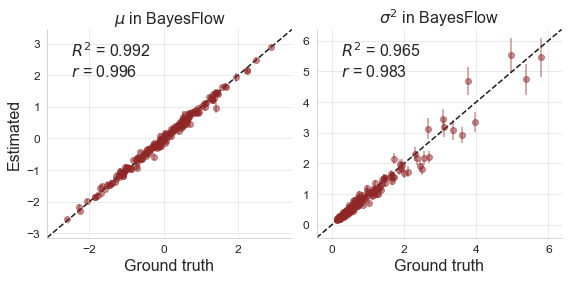

In [19]:
new_sims = trainer.configurator(trainer.generative_model(200))
posterior_draws = amortizer.sample(new_sims, n_samples=500)
fig = bf.diagnostics.plot_recovery(posterior_draws, new_sims["parameters"])


fig.axes[0].set_title(r"$\mu$ in BayesFlow", fontsize=16)
fig.axes[1].set_title(r"$\sigma^2$ in BayesFlow", fontsize=16)
plt.show()

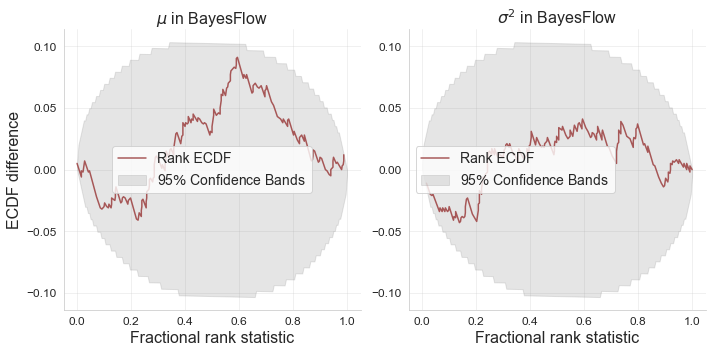

In [32]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_draws, new_sims["parameters"], difference=True)

fig.axes[0].set_title(r"$\mu$ in BayesFlow", fontsize=16)
fig.axes[1].set_title(r"$\sigma^2$ in BayesFlow", fontsize=16)
plt.show()

In [21]:
import numpy as np
import tensorflow_probability as tfp

def bayes_estimator(data, mu_0=0, sigma_0 = 1,kappa_0=1, alpha_0=2, beta_0=1, n_samples=1000):
    """
    Conjugate Normal-Inverse-Gamma posterior update for data ~ N(mu, sigma^2).
    Prior:   mu|sigma^2 ~ N(mu_0, sigma^2/kappa_0),
             sigma^2    ~ InvGamma(alpha_0, beta_0).

    Returns samples from the joint posterior p(mu, sigma^2 | data).
    """
    data = np.array(data).squeeze()
    n = len(data)
    sample_mean = np.mean(data)
    sample_var_sum = np.sum((data - sample_mean)**2)  # S

    # Posterior parameters
    kappa_n = kappa_0 + n
    alpha_n = alpha_0 + 0.5 * n
    beta_n = beta_0 \
             + 0.5 * sample_var_sum \
             + 0.5 * (kappa_0 * n / kappa_n) * (sample_mean - mu_0)**2

    mu_n = (kappa_0 * mu_0 + n * sample_mean) / kappa_n

    # 1) Sample sigma^2 from InvGamma(alpha_n, beta_n)
    #    (TFP's InverseGamma uses 'concentration' and 'scale' parameters)
    ig = tfp.distributions.InverseGamma(concentration=alpha_n, scale=beta_n)
    sigma2_samples = ig.sample(n_samples)

    # 2) For each sigma^2 draw, sample mu ~ Normal(mu_n, sigma^2 / kappa_n)
    #    We can do this in vectorized form
    mu_stddev = tf.sqrt(sigma2_samples / kappa_n)
    normal_dist = tfp.distributions.Normal(loc=mu_n, scale=mu_stddev)
    mu_samples = normal_dist.sample()

    return mu_samples.numpy(), sigma2_samples.numpy()


In [29]:
n_obs = 100  # Number of samples
true_miu = 0.4   # True mean
true_sigma = 0.7  # True standard deviation

obs_data= np.random.normal(loc=true_miu, scale=true_sigma, size=(n_obs, 1)).astype(np.float32)
# obs_data = np.hstack([obs_data_1, obs_data_1])  # 水平拼接两列

Z = obs_data  # 记住 Z，后续可能需要用到
obs_data = obs_data[np.newaxis, :, :]  # reshape 成 (1, n_obs, 2)

summary_vector = summary_net(obs_data).numpy()
posterior_samples = amortizer.sample({"summary_conditions": obs_data}, n_samples=100)

reference_posterior_mu, reference_posterior_sigma = bayes_estimator(obs_data)

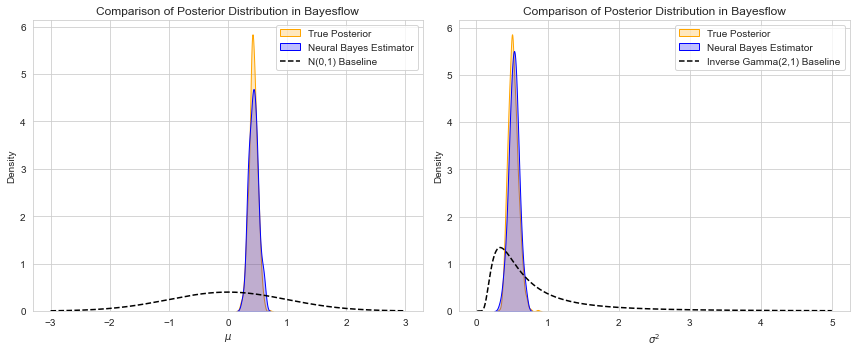

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ======== Create subplots ========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Arrange two plots horizontally

# ======== Left plot: Comparison of True vs. Neural Posterior with N(0,1) ========
# Plot true posterior
sns.kdeplot(reference_posterior_mu, label="True Posterior", fill=True, color="orange", ax=axes[0])

# Plot inferred posterior
sns.kdeplot(posterior_samples[:, 0], label="Neural Bayes Estimator", fill=True, color="blue", ax=axes[0])

# Generate density curve for N(0,1)
x = np.linspace(-3, 3, 1000)
y = stats.norm.pdf(x, loc=0, scale=1)
axes[0].plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")

# Axis labels and legend
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"Comparison of Posterior Distribution in Bayesflow")
axes[0].legend()


# ======== Right plot: Comparison of True vs. Neural Posterior with Inverse Gamma ========
# Plot true posterior
sns.kdeplot(reference_posterior_sigma, label="True Posterior", fill=True, color="orange", ax=axes[1])

# Plot inferred posterior
sns.kdeplot(posterior_samples[:, 1], label="Neural Bayes Estimator", fill=True, color="blue", ax=axes[1])

# Generate density curve for Inverse Gamma(2,1)
x = np.linspace(0.01, 5, 1000)
y = stats.invgamma.pdf(x, a=2, scale=1)
axes[1].plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

# Axis labels and legend
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Comparison of Posterior Distribution in Bayesflow")
axes[1].legend()


# ======== Adjust layout ========
plt.tight_layout()
plt.show()
